## Hometask

Mine top 10 association rules worth recommending for Groceries dataset

Import Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from apyori import apriori

Load data set

In [53]:
df = pd.read_csv('Data/Groceries_dataset.csv')
df.head() 

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [54]:
len(df)

38765

(array([1.008e+04, 2.698e+03, 1.390e+03, 3.440e+02, 1.750e+02, 8.000e+01,
        1.450e+02, 5.000e+01, 0.000e+00, 1.000e+00]),
 array([ 2. ,  2.9,  3.8,  4.7,  5.6,  6.5,  7.4,  8.3,  9.2, 10.1, 11. ]),
 <BarContainer object of 10 artists>)

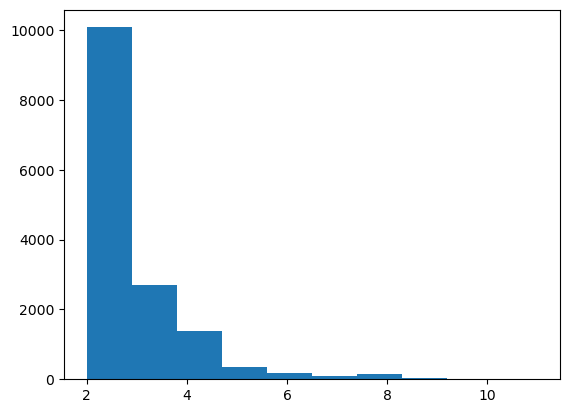

In [55]:
dist = [len(g) for k, g in df.groupby(['Member_number', 'Date'])]
plt.hist(dist)

Fill missed

In [56]:
df= df.fillna(0)

In [57]:
trans= df.values.tolist()
trans[:5]

[[1808, '21-07-2015', 'tropical fruit'],
 [2552, '05-01-2015', 'whole milk'],
 [2300, '19-09-2015', 'pip fruit'],
 [1187, '12-12-2015', 'other vegetables'],
 [3037, '01-02-2015', 'whole milk']]

Data preparation

In [58]:
transactions = df.groupby('Member_number')['itemDescription'].apply(list).values.tolist()



Learn rules

In [59]:
rules = list(apriori(transactions, min_support = 0.003, min_confidence = 0.2, min_lift = 4, min_length = 2))
rules[:3]

[RelationRecord(items=frozenset({'canned beer', 'beverages', 'meat'}), support=0.0030785017957927143, ordered_statistics=[OrderedStatistic(items_base=frozenset({'canned beer', 'beverages'}), items_add=frozenset({'meat'}), confidence=0.27906976744186046, lift=4.3863465866466615)]),
 RelationRecord(items=frozenset({'pastry', 'red/blush wine', 'dessert'}), support=0.0035915854284248334, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pastry', 'red/blush wine'}), items_add=frozenset({'dessert'}), confidence=0.358974358974359, lift=4.152172258997185)]),
 RelationRecord(items=frozenset({'domestic eggs', 'meat spreads', 'whole milk'}), support=0.0033350436121087736, ordered_statistics=[OrderedStatistic(items_base=frozenset({'meat spreads'}), items_add=frozenset({'domestic eggs', 'whole milk'}), confidence=0.37142857142857144, lift=5.284045881126173)])]

In [60]:
len(rules)

90

Print rules with more details

In [63]:
def print_rules(rules): 
    for rule in rules:
        print ('rule.items=', list(rule.items))
        print ('rule.support=',rule.support)

        for os in rule.ordered_statistics:
            print ('\titems_base=', list(os.items_base))
            print ('\tlifted_item =', list(os.items_add))
            print ('\tlift=', os.lift)
            print ('\tconfidence (i.e. cond prob {} if {})='.format(list(os.items_add), list(os.items_base)), os.confidence)
            print ('\n')
        
print_rules(rules[:5])

rule.items= ['canned beer', 'beverages', 'meat']
rule.support= 0.0030785017957927143
	items_base= ['canned beer', 'beverages']
	lifted_item = ['meat']
	lift= 4.3863465866466615
	confidence (i.e. cond prob ['meat'] if ['canned beer', 'beverages'])= 0.27906976744186046


rule.items= ['pastry', 'red/blush wine', 'dessert']
rule.support= 0.0035915854284248334
	items_base= ['pastry', 'red/blush wine']
	lifted_item = ['dessert']
	lift= 4.152172258997185
	confidence (i.e. cond prob ['dessert'] if ['pastry', 'red/blush wine'])= 0.358974358974359


rule.items= ['domestic eggs', 'meat spreads', 'whole milk']
rule.support= 0.0033350436121087736
	items_base= ['meat spreads']
	lifted_item = ['domestic eggs', 'whole milk']
	lift= 5.284045881126173
	confidence (i.e. cond prob ['domestic eggs', 'whole milk'] if ['meat spreads'])= 0.37142857142857144


rule.items= ['sausage', 'onions', 'sliced cheese']
rule.support= 0.0035915854284248334
	items_base= ['sausage', 'onions']
	lifted_item = ['sliced cheese

Get association rules

In [110]:
top_rules = []
for rule in rules:
    for os in rule.ordered_statistics:
        top_rules.append({
            'rule': f"{list(os.items_base)} → {list(os.items_add)}",
            'support': rule.support,
            'confidence': os.confidence,
            'lift': os.lift
        })


Sort by confidence

In [111]:
top_rules.sort(key=lambda x: x['confidence'], reverse=True)

Print atop 10 association rules worth recommending for Groceries dataset

In [112]:
def print_rules(top_rules): 
    for i, rule in enumerate(top_rules[:10], 1):
        print(f"{i}. {rule['rule']}")
        print(f"Support: {rule['support']}")
        print(f"Confidence: {rule['confidence']}")
        print(f"Lift: {rule['lift']}")
        print()
        

print_rules(top_rules)

1. ['sliced cheese', 'waffles'] → ['yogurt', 'whole milk']
Support: 0.0030785017957927143
Confidence: 0.8
Lift: 5.312436115843271

2. ['yogurt', 'soda', 'whole milk', 'specialty chocolate'] → ['citrus fruit']
Support: 0.0030785017957927143
Confidence: 0.75
Lift: 4.04356846473029

3. ['berries', 'pork', 'bottled water'] → ['yogurt', 'whole milk']
Support: 0.0030785017957927143
Confidence: 0.7058823529411765
Lift: 4.687443631626415

4. ['pork', 'beverages', 'other vegetables'] → ['soda', 'whole milk']
Support: 0.0030785017957927143
Confidence: 0.6315789473684211
Lift: 4.179787329103744

5. ['pork', 'white bread', 'other vegetables'] → ['soda', 'whole milk']
Support: 0.0035915854284248334
Confidence: 0.6086956521739131
Lift: 4.0283457592086815

6. ['yogurt', 'whole milk', 'curd', 'shopping bags'] → ['brown bread']
Support: 0.0033350436121087736
Confidence: 0.5909090909090909
Lift: 4.345969125214409

7. ['sausage', 'rolls/buns', 'bottled water', 'root vegetables'] → ['soda', 'other vegetab